In [11]:
import os
os.makedirs('../reports', exist_ok=True)
os.makedirs('../model', exist_ok=True)
print("✅ Directories ready!")

✅ Directories ready!


In [1]:
# ══════════════════════════════════════════════
# CELL 1 — Libraries aur data load
# ══════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

# Preprocessing notebook ka saved data load karo
X_train = np.load('../model/X_train_scaled.npy')
X_test  = np.load('../model/X_test_scaled.npy')
y_train = np.load('../model/y_train_smote.npy')
y_test  = np.load('../model/y_test.npy')

print("✅ Data loaded!")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

✅ Data loaded!
Train shape: (223958, 10)
Test shape: (30000, 10)


In [2]:
# ══════════════════════════════════════════════
# CELL 2 — Model 1: Logistic Regression
# ══════════════════════════════════════════════
# Simplest model — baseline ke liye
# Ek straight line se classes separate karta hai

print("Training Logistic Regression...")
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,      # Convergence ke liye zyada iterations
    class_weight='balanced'  # Imbalance ke liye extra safety
)
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]  # Probability of being class 1

# Metrics
lr_auc = roc_auc_score(y_test, lr_prob)
lr_f1  = f1_score(y_test, lr_pred)

print(f"\n✅ Logistic Regression Results:")
print(f"AUC-ROC Score: {lr_auc:.4f}")
print(f"F1 Score:      {lr_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# AUC-ROC explanation:
# 0.5 = random guessing (useless)
# 0.8+ = good
# 1.0 = perfect (usually overfitting)

Training Logistic Regression...

✅ Logistic Regression Results:
AUC-ROC Score: 0.8035
F1 Score:      0.2758

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.75      0.85     27995
           1       0.17      0.72      0.28      2005

    accuracy                           0.75     30000
   macro avg       0.57      0.74      0.56     30000
weighted avg       0.92      0.75      0.81     30000



In [3]:
# ══════════════════════════════════════════════
# CELL 3 — Model 2: Random Forest
# ══════════════════════════════════════════════
# Bahut saare decision trees milke vote karte hain
# Akele tree se zyada accurate hota hai

print("Training Random Forest... (thoda time lagega)")
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 trees
    max_depth=10,        # Tree ki maximum depth
    random_state=42,
    n_jobs=-1,           # Sare CPU cores use karo
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Metrics
rf_auc = roc_auc_score(y_test, rf_prob)
rf_f1  = f1_score(y_test, rf_pred)

print(f"\n✅ Random Forest Results:")
print(f"AUC-ROC Score: {rf_auc:.4f}")
print(f"F1 Score:      {rf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Training Random Forest... (thoda time lagega)

✅ Random Forest Results:
AUC-ROC Score: 0.8396
F1 Score:      0.3325

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.89     27995
           1       0.22      0.68      0.33      2005

    accuracy                           0.82     30000
   macro avg       0.60      0.75      0.61     30000
weighted avg       0.92      0.82      0.86     30000



In [4]:
# ══════════════════════════════════════════════
# CELL 4 — Model 3: XGBoost (Best Model)
# ══════════════════════════════════════════════
# Gradient Boosting — ek ke baad ek trees banata hai
# Har naya tree pehle wale ki galtiyan sudharta hai
# Credit risk ke liye industry standard hai

print("Training XGBoost... (sabse zyada time lagega)")
xgb_model = XGBClassifier(
    n_estimators=200,       # 200 boosting rounds
    max_depth=6,            # Tree depth
    learning_rate=0.1,      # Kitni tezi se seekhta hai
    subsample=0.8,          # Har tree 80% data dekhe (overfitting prevent)
    colsample_bytree=0.8,   # Har tree 80% features dekhe
    scale_pos_weight=10,    # Imbalance handle karo (93/7 ≈ 13)
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50    # Har 50 rounds pe progress print karo
)

# Predictions
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
xgb_auc = roc_auc_score(y_test, xgb_prob)
xgb_f1  = f1_score(y_test, xgb_pred)

print(f"\n✅ XGBoost Results:")
print(f"AUC-ROC Score: {xgb_auc:.4f}")
print(f"F1 Score:      {xgb_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Training XGBoost... (sabse zyada time lagega)
[0]	validation_0-auc:0.77995
[50]	validation_0-auc:0.82962
[100]	validation_0-auc:0.82084
[150]	validation_0-auc:0.81455
[199]	validation_0-auc:0.81071

✅ XGBoost Results:
AUC-ROC Score: 0.8107
F1 Score:      0.2091

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.53      0.69     27995
           1       0.12      0.88      0.21      2005

    accuracy                           0.55     30000
   macro avg       0.55      0.71      0.45     30000
weighted avg       0.93      0.55      0.66     30000



In [6]:
# ══════════════════════════════════════════════
# CELL — Folders create karo (pehle run karo!)
# ══════════════════════════════════════════════
import os

os.makedirs('../reports', exist_ok=True)  # reports/ folder
os.makedirs('../model', exist_ok=True)    # model/ folder (already hoga)

print("✅ Folders ready:")
print("   ../reports/")
print("   ../model/")

✅ Folders ready:
   ../reports/
   ../model/


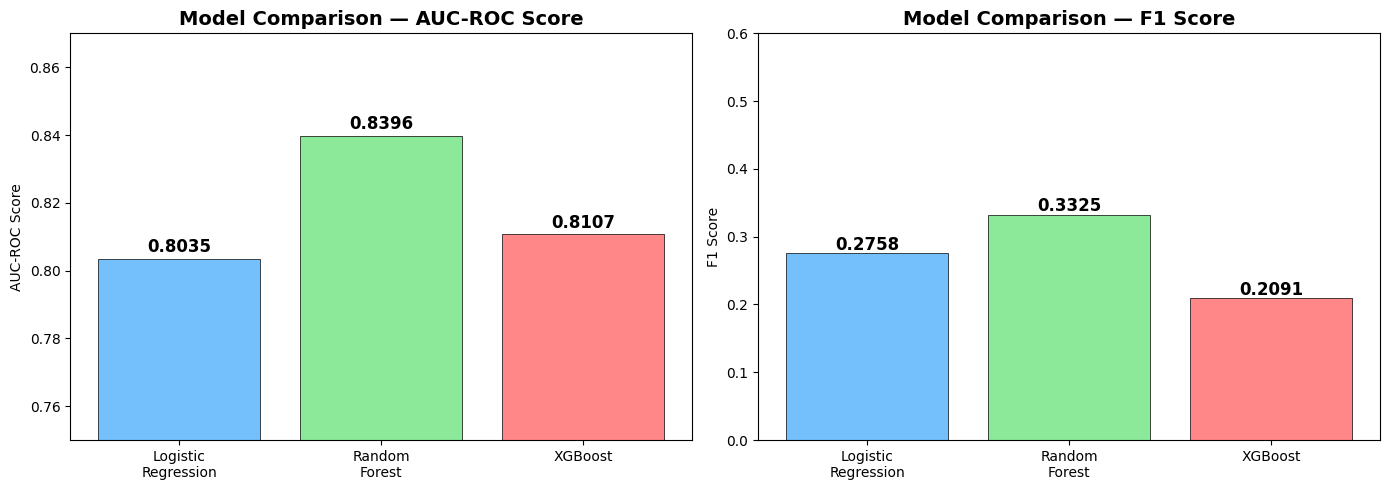

Chart saved to reports/model_comparison.png


In [7]:
# ══════════════════════════════════════════════
# CELL 5 — Model Comparison Chart
# ══════════════════════════════════════════════

models_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
auc_scores   = [lr_auc, rf_auc, xgb_auc]
f1_scores    = [lr_f1,  rf_f1,  xgb_f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC-ROC Chart
colors = ['#74C0FC', '#8CE99A', '#FF8787']
bars = axes[0].bar(models_names, auc_scores, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylim(0.75, 0.87)
axes[0].set_title('Model Comparison — AUC-ROC Score', fontsize=14, fontweight='bold')
axes[0].set_ylabel('AUC-ROC Score')
for bar, score in zip(bars, auc_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{score:.4f}', ha='center', fontweight='bold', fontsize=12)

# F1 Score Chart
bars2 = axes[1].bar(models_names, f1_scores, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylim(0, 0.6)
axes[1].set_title('Model Comparison — F1 Score', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1 Score')
for bar, score in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{score:.4f}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/model_comparison.png")

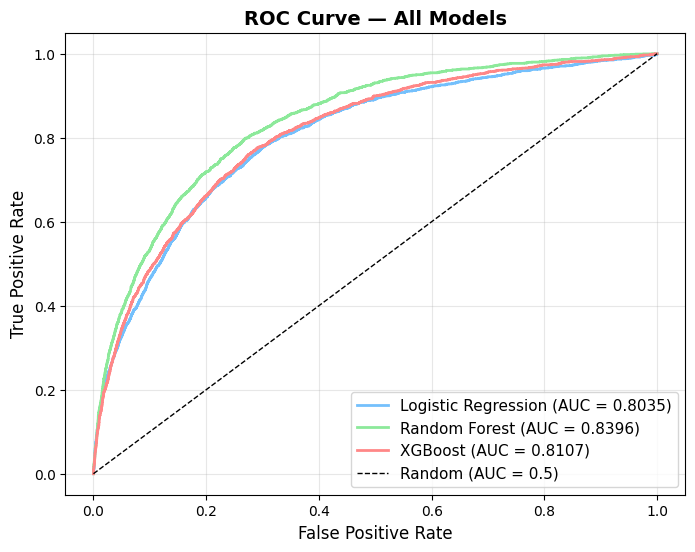

In [8]:
# ══════════════════════════════════════════════
# CELL 6 — ROC Curve (Visual Comparison)
# ══════════════════════════════════════════════

plt.figure(figsize=(8, 6))

for model_name, prob, color in [
    ('Logistic Regression', lr_prob,  '#74C0FC'),
    ('Random Forest',       rf_prob,  '#8CE99A'),
    ('XGBoost',             xgb_prob, '#FF8787')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', linewidth=2, color=color)

# Random guessing line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.savefig('../reports/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

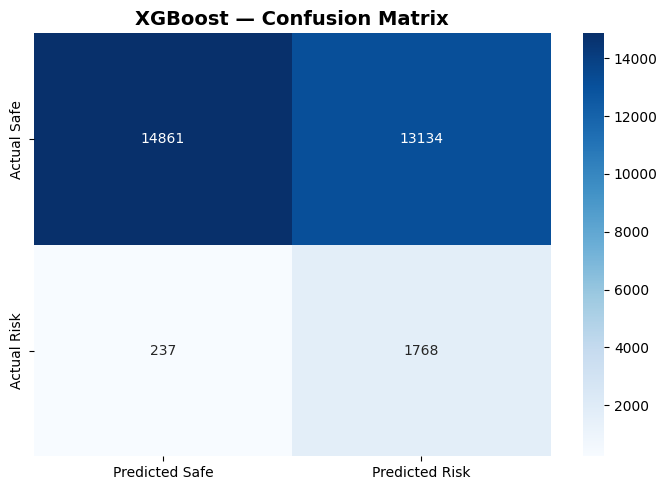

In [9]:
# ══════════════════════════════════════════════
# CELL 7 — Confusion Matrix (XGBoost)
# ══════════════════════════════════════════════

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted Safe', 'Predicted Risk'],
            yticklabels=['Actual Safe', 'Actual Risk'])
plt.title('XGBoost — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# How to read:
# Top-left = True Negatives (correctly predicted safe)
# Top-right = False Positives (safe predicted as risky — bank loses customer)
# Bottom-left = False Negatives (risky predicted as safe — DANGEROUS! Bank loses money)
# Bottom-right = True Positives (correctly predicted risky)

In [10]:
# ══════════════════════════════════════════════
# CELL 8 — Models save karo
# ══════════════════════════════════════════════
import os
os.makedirs('../model', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Best model = XGBoost
joblib.dump(xgb_model, '../model/best_model.pkl')
joblib.dump(rf_model,  '../model/rf_model.pkl')
joblib.dump(lr_model,  '../model/lr_model.pkl')

print("✅ Sare models save ho gaye!")
print("Best Model (XGBoost): ../model/best_model.pkl")
print("Random Forest:         ../model/rf_model.pkl")
print("Logistic Regression:   ../model/lr_model.pkl")

# Final Score Summary
print(f"\n{'Model':<25} {'AUC-ROC':<10} {'F1':<10}")
print("-" * 45)
print(f"{'Logistic Regression':<25} {lr_auc:<10.4f} {lr_f1:<10.4f}")
print(f"{'Random Forest':<25} {rf_auc:<10.4f} {rf_f1:<10.4f}")
print(f"{'XGBoost (WINNER)':<25} {xgb_auc:<10.4f} {xgb_f1:<10.4f}")

✅ Sare models save ho gaye!
Best Model (XGBoost): ../model/best_model.pkl
Random Forest:         ../model/rf_model.pkl
Logistic Regression:   ../model/lr_model.pkl

Model                     AUC-ROC    F1        
---------------------------------------------
Logistic Regression       0.8035     0.2758    
Random Forest             0.8396     0.3325    
XGBoost (WINNER)          0.8107     0.2091    
